<!--- sf-header --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fscale-forecasting%2Fmain%2Fnotebooks%2F03_combo_and_ensemble.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
</tr>
</table>
<br clear="left"/>

> **Run in Colab Enterprise:** click the badge to import this notebook, pick a runtime, and
> **Run all**. The Terraform-deployed templates already carry the `SF_*` run identity in their env,
> so there's no environment cell to fill in. Runs on the **`sf-main`** runtime template (Python 3.11). See
> [`docs/notebook_runtimes.md`](https://github.com/statmike/scale-forecasting/blob/main/docs/notebook_runtimes.md)
> for the per-notebook template mapping and the headless acceptance harness.


# 03 · Combo + ensembles (one run_id)

The payoff. One config mixes a **Spark** model (`theta`) with the **BigQuery-native** models, and turns **ensembles on**. `main.run(cfg)` runs both compute tracks **in parallel under one `run_id`**, then — after both engines join — fires the **ensembler**: it blends the base forecasts (mean / median / inverse-error), scores each consensus against held-out actuals, and writes the results so they land on the *same* leaderboard as the base models.

One `v_model_leaderboard` query then shows **base Spark + base BigQuery + `ensemble_*`** side by side.

## Get the code (cloud runtimes only)

On a cloud notebook (Colab Enterprise, Vertex Workbench) this clones or updates the repo so you're on the latest `src/`. **Skip it in a local clone** — it's a no-op guarded on the package already being importable.

In [1]:
# Cloud bootstrap: clone + install the LOCKED dependency set (uv.lock) so
# `import scale_forecasting` resolves against the exact versions every other surface runs.
# Uses uv (Colab ships it; we install it if missing) to install the frozen lock into a PRIVATE
# prefix, then puts that prefix + src/ first on sys.path. Harmless locally — if it already imports,
# no-op.
import importlib.util
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")

EXTRAS = []  # this notebook needs only the core

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    uv = shutil.which("uv")
    if uv is None:  # Colab Enterprise ships uv; install it if this runtime doesn't
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
        uv = shutil.which("uv") or "uv"
    # Resolve the checked-in lock to a requirements file (no re-resolve), then install EXACTLY
    # that set into this kernel — the same versions the container + packed-venv are built from.
    reqs = os.path.abspath(os.path.join(REPO_DIR, "colab-requirements.txt"))
    extra_flags = [f for e in EXTRAS for f in ("--extra", e)]
    subprocess.run(
        [uv, "export", "--frozen", "--no-emit-project", "--no-hashes", "--no-dev", *extra_flags,
         "-o", reqs],
        cwd=REPO_DIR, check=True,
    )
    # Install the LOCKED set into a PRIVATE directory (not the runtime's system site-packages),
    # then put it FIRST on sys.path. Managed images (Colab Enterprise, Vertex) ship numpy 2.x that
    # can't be cleanly downgraded in place: uv skips the version-satisfied packages it can't fully
    # uninstall, so numpy-2 .so files end up beside numpy-1 python and `import numpy` dies with
    # "dtype size changed, Expected 96 ... got 88". Installing to a separate prefix and SHADOWING the
    # base packages (never touching them) gives this kernel a clean, self-consistent numpy 1.26.4 —
    # the same set every other surface runs — with zero risk of a mixed install.
    target = os.path.abspath(os.path.join(REPO_DIR, ".colab-deps"))
    subprocess.run(
        [uv, "pip", "install", "--python", sys.executable, "--target", target, "-r", reqs],
        check=True,
    )
    # src/ carries our package; `target` carries its locked deps. Both go ahead of the base image's
    # site-packages so imports resolve to the versions we installed, not the runtime's.
    sys.path.insert(0, target)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))

## Resolve the deployment (live GCP)

`Settings.resolve()` reads the `SF_*` environment — the *same* identity every writer uses, so a notebook run and a Composer run land in the same registry. Required: `SF_PROJECT_ID`, `SF_CONNECTION`, `SF_WAREHOUSE_URI`; `SF_DATASET_ID`/`SF_REGION` default. This demo targets the live `run_registry` + `v_model_leaderboard` / `v_run_summary`.

In [2]:
from google.cloud import bigquery

from scale_forecasting.settings import Settings

settings = Settings.resolve()
client = bigquery.Client(project=settings.project_id)
DATASET = settings.dataset_ref
print("deployment:", DATASET, "region:", settings.region)

deployment: statmike-scale-forecasting.scale_forecasting region: us-central1


## Review helpers

Registry rows written through the Storage Write API are *async-visible*, so we poll the leaderboard briefly until a run's models show up. `leaderboard(run_id)` returns one row per model — `compute_engine` splits Spark / BigQuery / ensemble — and `run_summary(run_id)` is the header roll-up.

In [3]:
import time

import pandas as pd


def _query(sql, run_id):
    job = client.query(
        sql,
        job_config=bigquery.QueryJobConfig(
            query_parameters=[bigquery.ScalarQueryParameter("run_id", "STRING", run_id)]
        ),
    )
    return job.result().to_dataframe()


def leaderboard(run_id, expect_models=None, tries=12, pause=3.0):
    """Poll v_model_leaderboard until `expect_models` all appear (or give up), newest metrics."""
    sql = (
        f"SELECT model_type, compute_engine, n_cells, mean_wape, mean_mae "
        f"FROM `{DATASET}.v_model_leaderboard` WHERE run_id=@run_id "
        f"ORDER BY mean_wape"
    )
    df = pd.DataFrame()
    for _ in range(tries):
        df = _query(sql, run_id)
        if expect_models is None or set(df["model_type"]) >= set(expect_models):
            break
        time.sleep(pause)
    return df


def run_summary(run_id):
    sql = f"SELECT * FROM `{DATASET}.v_run_summary` WHERE run_id=@run_id"
    return _query(sql, run_id)

## Parameters — edit me

Everything that shapes the run is set here as plain Python, then assembled into a **`RunConfig`** — the one frozen object that drives the run and is logged verbatim to `run_registry.raw_config`, so *this cell is the experiment record*. No separate JSON file to open.

- **`RUN_NAME`** carries a timestamp so each execution is its own clean run (the cell tables are append-only, so a fresh `run_id` avoids overwriting a still-buffering prior run).
- **`SOURCE_TABLE`** picks the storage format of the shipped input — `source_series_iceberg` (managed Apache Iceberg) or `source_series_native` (native BigQuery), identical series. Both the Spark and BigQuery tracks read whichever you name through the same table interface.
- **`MODELS`** mixes runtimes automatically: `theta` runs on **Spark** (`compute_engine='spark'`) while `arima_plus`/`timesfm` run in **BigQuery** — the router splits them by model.
- **`BACKTEST=True`** so the Spark path emits an OOF metric panel comparable to the natives; **`ENSEMBLE_STRATEGIES`** triggers the ensembler after the engine join (blends the base forecasts and scores each consensus).

In [4]:
from scale_forecasting import main
from scale_forecasting.config import RunConfig
from scale_forecasting.registry.ids import make_run_id

# === Parameters — edit me ===============================================
RUN_NAME = f"nb03 combo ensemble {int(time.time())}"  # timestamped → a fresh run each execution
SOURCE_TABLE = "source_series_iceberg"  # shipped seed (100k); _iceberg↔_native to compare storage
MODELS = ["theta", "arima_plus", "timesfm"]  # theta → Spark; arima_plus/timesfm → BigQuery
HORIZON = 28
SERIES_LIMIT = 10  # small subset so the demo is quick + cheap
HOLIDAYS = ["US"]
BACKTEST = True  # OOF panel so ensembles can be scored/learned
N_FOLDS = 2
ENSEMBLE_STRATEGIES = ["mean", "median", "inverse_error"]
# ========================================================================

cfg = RunConfig(
    run_name=RUN_NAME,
    python_runtime="spark",
    data={"source_table": SOURCE_TABLE, "horizon": HORIZON, "series_limit": SERIES_LIMIT},
    models=MODELS,  # router splits Spark vs BigQuery automatically
    features={"holidays": HOLIDAYS},
    backtest={"enabled": BACKTEST, "n_folds": N_FOLDS, "horizon": HORIZON, "step": HORIZON},
    ensemble={"enabled": True, "strategies": ENSEMBLE_STRATEGIES},
)
run_id = make_run_id(cfg)
print("run_id:", run_id)
print("  models:", cfg.models)
print("  ensemble strategies:", cfg.ensemble.strategies)

returned = main.run(cfg)
assert returned == run_id
print("combo + ensemble run complete:", run_id)

run_id: nb03-combo-ensemble-1789919864-67b161ae368e
  models: ['theta', 'arima_plus', 'timesfm']
  ensemble strategies: ['mean', 'median', 'inverse_error']


combo + ensemble run complete: nb03-combo-ensemble-1789919864-67b161ae368e


## Review — base models and ensembles together

Base `theta` (`compute_engine='spark'`), the natives (`bigquery`), and each `ensemble_*` (`ensemble`) all on one board, ordered by `mean_wape`. If an ensemble beats every base model, it sits at the top.

In [5]:
expect = list(cfg.models) + [f"ensemble_{s}" for s in cfg.ensemble.strategies]
board = leaderboard(run_id, expect_models=expect)
board

,model_type,compute_engine,n_cells,mean_wape,mean_mae
0,arima_plus,bigquery,10,0.384178,13.203770
1,ensemble_median,ensemble,10,0.390193,13.542568
2,timesfm,bigquery,10,0.391546,13.521361
3,ensemble_inverse_error,ensemble,10,0.397878,13.428206
4,ensemble_mean,ensemble,10,0.401049,13.900045
5,theta,spark,10,0.451080,17.672324


## The showpiece chart

`mean_wape` per model, colored by compute engine — base vs ensemble at a glance (lower is better).

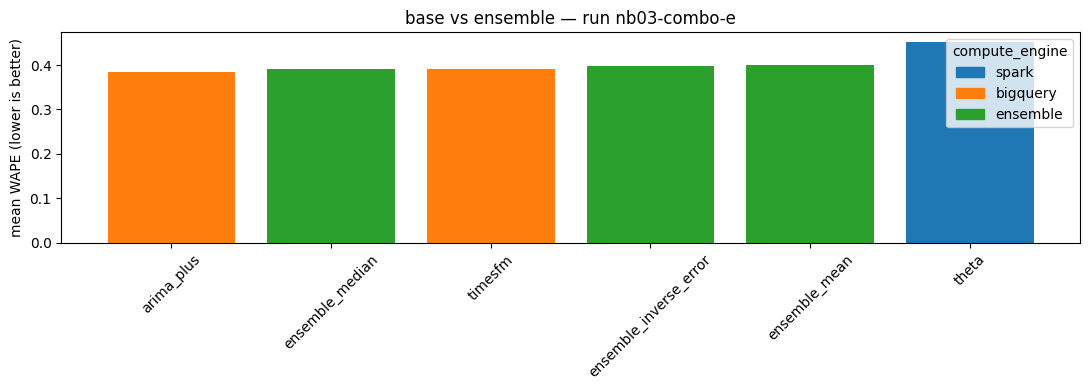

In [6]:
import matplotlib.pyplot as plt

plot_df = board.dropna(subset=["mean_wape"]).sort_values("mean_wape")
colors = {"spark": "#1f77b4", "bigquery": "#ff7f0e", "ensemble": "#2ca02c"}
bar_colors = [colors.get(e, "#888888") for e in plot_df["compute_engine"]]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(plot_df["model_type"], plot_df["mean_wape"], color=bar_colors)
ax.set_ylabel("mean WAPE (lower is better)")
ax.set_title(f"base vs ensemble — run {run_id[:12]}")
ax.tick_params(axis="x", rotation=45)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
ax.legend(handles, colors.keys(), title="compute_engine")
plt.tight_layout()
plt.show()

In [7]:
run_summary(run_id)

,run_id,created_at,status,python_runtime,n_series,n_models,backtest_on,runtime_seconds,total_wall_s,overhead_seconds,overhead_fraction,executor_instances,executor_cores,max_executors,executor_memory,executor_memory_overhead,dcu_milli_seconds,runtime_version,sizing,capacity
0,nb03-combo-ensemble-1789919864-67b161ae368e,2026-09-20 15:57:56.242713+00:00,COMPLETED,spark,10,3,True,1588.539876,1462.1,-126.439876,-0.086478,<NA>,<NA>,<NA>,None,None,14546400,2.2.86,"{""statistical"":{""family"":""statistical"",""plans""...",None
